# Chapter 14: Projective Geometry

Source orientation: Coxeter, *Introduction to Geometry*, Chapter 14, printed pages 229-262, PDF pages 247-280. The source pages were inspected as scanned page images; this notebook is an original computational lesson and does not copy textbook prose, figures, page crops, or exercise statements.

## Chapter Goal

The goal is to make the projective move visible: discard metric structure, keep incidence and cross-ratio, then recover affine and Euclidean geometry by choosing extra projective data. By the end, points, lines, conics, correlations, three-dimensional projective space, and Euclidean orthogonality should all be readable as homogeneous-coordinate statements that can be checked.

## Computational Translation Guide

| Source idea | Computational representation | Check used here |
| --- | --- | --- |
| Projective plane axioms | points and lines as homogeneous triples, incidence as a dot product | finite `PG(2,3)` counts, unique joins/meets, diagonal-point test, Pappus sample |
| Projective coordinates | point `[x1:x2:x3]`, line `l1 x1 + l2 x2 + l3 x3 = 0` | cross products for join and meet |
| Desargues theorem | two triangles with corresponding vertices on concurrent lines | three corresponding side intersections have determinant zero |
| Quadrangular and harmonic sets | a line cutting opposite sides of a complete quadrangle | harmonic cross-ratio equals `-1` |
| Projectivities | fractional linear maps on a range | symbolic and numeric cross-ratio invariance |
| Collineations | nonsingular homogeneous matrices and image homographies | OpenCV reprojection and line residuals |
| Correlations and polarities | point-to-line map from a bilinear form | pole/polar incidence and symmetric-matrix polarity check |
| Conics | self-conjugate locus of a polarity, or a quadratic equation | tangent/polar identity and Pascal collinearity |
| Projective space | planes, skew lines, reguli, quadrics | ruled-quadric residuals in 3D |
| Euclidean space | affine chart plus an absolute polarity at infinity | dot-product orthogonality among directions |


In [1]:
from pathlib import Path
import sys
import csv
import json
import math
from itertools import combinations

import cv2
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import plotly.graph_objects as go

from IPython.display import Markdown, display

CHAPTER_NO = 14
HERE = Path.cwd().resolve()
search_roots = [HERE, *HERE.parents, HERE / "Introduction-to-Geometry"]
BOOK_ROOT = None
for candidate in search_roots:
    if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
        BOOK_ROOT = candidate
        break
if BOOK_ROOT is None:
    raise RuntimeError("Could not locate Introduction-to-Geometry book root")
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import (
    assert_artifacts,
    book_relative,
    display_artifact,
    ensure_chapter_artifact_dirs,
    write_csv,
    write_json,
)
from utils.course import chapter_by_no

chapter = chapter_by_no(CHAPTER_NO)
ART = ensure_chapter_artifact_dirs(CHAPTER_NO, BOOK_ROOT)


chapter_checks = {
    "chapter": CHAPTER_NO,
    "source_span": {"printed_pages": "229-262", "pdf_pages": "247-280"},
}
artifact_records = []

def artifact(kind, filename, concept, role, library):
    path = ART[kind] / filename
    artifact_records.append({
        "concept": concept,
        "kind": kind,
        "path": book_relative(path, BOOK_ROOT),
        "role": role,
        "library": library,
    })
    return path

def savefig(path, fig):
    fig.savefig(path, dpi=180, bbox_inches="tight")
    plt.close(fig)
    return path

storyboard = {
    "chapter_goal": "Teach projective geometry as incidence plus homogeneous-coordinate invariants, then recover affine and Euclidean structure by specializing extra data.",
    "source_span_read": "printed pages 229-262 / PDF pages 247-280 inspected from the scanned PDF",
    "visual_sequence": [
        "projective-plane axioms and the line at infinity",
        "homogeneous coordinates as join/meet cross products",
        "Desargues axis as a determinant invariant",
        "quadrangle section producing a harmonic cross-ratio",
        "projectivity as cross-ratio preserving fractional linear map",
        "OpenCV homography as a concrete collineation",
        "polarity and conic tangents from a symmetric bilinear form",
        "Pascal line for six points on a conic",
        "projective-space regulus on a ruled quadric",
        "Euclidean orthogonality from an absolute polarity at infinity",
    ],
    "libraries": {
        "Matplotlib": "durable 2D incidence, proof, and conic diagrams",
        "SymPy": "exact homogeneous-coordinate and cross-ratio identities",
        "OpenCV": "synthetic homography/collineation check with reprojection residuals",
        "Plotly": "interactive 3D projective-space and absolute-polarity artifacts",
    },
}
write_json(ART["checks"] / "storyboard.json", storyboard)
artifact_records.append({
    "concept": "chapter storyboard",
    "kind": "checks",
    "path": book_relative(ART["checks"] / "storyboard.json", BOOK_ROOT),
    "role": "implementation plan and source-specific visual sequence",
    "library": "json",
})

display(Markdown(f"Loaded **{chapter['title']}**. Artifact root: `{book_relative(ART['figures'].parent, BOOK_ROOT)}`"))


Loaded **Projective Geometry**. Artifact root: `artifacts/chapter-14`

In [2]:
EPS = 1e-9

def hp(x, y, w=1.0):
    return np.array([float(x), float(y), float(w)])

def join(p, q):
    return np.cross(p, q)

def meet(l, m):
    return np.cross(l, m)

def normalize_point(p):
    p = np.asarray(p, dtype=float)
    if abs(p[2]) > EPS:
        return p / p[2]
    n = np.linalg.norm(p[:2])
    if n < EPS:
        raise ValueError("zero homogeneous point")
    return p / n

def affine(p):
    p = normalize_point(p)
    return p[:2]

def incidence(line, point):
    return float(np.dot(line, point))

def collinearity_residual(*points):
    return float(np.linalg.det(np.vstack(points)))

def line_segment_in_box(line, xlim=(-3, 3), ylim=(-3, 3)):
    a, b, c = [float(v) for v in line]
    pts = []
    for x in xlim:
        if abs(b) > EPS:
            y = -(a * x + c) / b
            if ylim[0] - EPS <= y <= ylim[1] + EPS:
                pts.append((x, y))
    for y in ylim:
        if abs(a) > EPS:
            x = -(b * y + c) / a
            if xlim[0] - EPS <= x <= xlim[1] + EPS:
                pts.append((x, y))
    unique = []
    for pt in pts:
        if not any(np.linalg.norm(np.array(pt) - np.array(q)) < 1e-7 for q in unique):
            unique.append(pt)
    if len(unique) >= 2:
        return unique[0], unique[1]
    return None

def draw_projective_line(ax, line, xlim=(-3, 3), ylim=(-3, 3), **kwargs):
    segment = line_segment_in_box(line, xlim, ylim)
    if segment is not None:
        (x0, y0), (x1, y1) = segment
        ax.plot([x0, x1], [y0, y1], **kwargs)

def cross_ratio(a, b, c, d):
    return ((c - a) / (c - b)) / ((d - a) / (d - b))

def point_on_line_parameter(a, b, x):
    av, bv, xv = affine(a), affine(b), affine(x)
    v = bv - av
    return float(np.dot(xv - av, v) / np.dot(v, v))

def annotate_point(ax, p, label, offset=(0.04, 0.04), **kwargs):
    xy = affine(p)
    ax.scatter([xy[0]], [xy[1]], s=36, zorder=4, **kwargs)
    ax.text(xy[0] + offset[0], xy[1] + offset[1], label, fontsize=9)

def mod_normalize(vec, p):
    vals = [int(v) % p for v in vec]
    if all(v == 0 for v in vals):
        raise ValueError("zero vector")
    for v in vals:
        if v != 0:
            inv = pow(v, -1, p)
            return tuple((inv * x) % p for x in vals)
    raise AssertionError("unreachable")

def mod_cross(a, b, p):
    c = np.cross(np.array(a, dtype=int), np.array(b, dtype=int))
    return mod_normalize(c, p)

def mod_dot(a, b, p):
    return sum((x * y) for x, y in zip(a, b)) % p

def finite_projective_plane(p):
    points = sorted({mod_normalize((x, y, z), p)
                     for x in range(p) for y in range(p) for z in range(p)
                     if (x, y, z) != (0, 0, 0)})
    lines = points[:]
    incidence = {(P, L): mod_dot(P, L, p) == 0 for P in points for L in lines}
    return points, lines, incidence


## 1. Projective-Plane Axioms: No Privileged Parallelism

The chapter begins by replacing parallelism with incidence. A projective line is closed: two distinct points determine one line, and two distinct lines determine one point. The affine model explains the familiar case: add one line at infinity, and parallel affine lines meet there.

The figure below has two roles. The left panel is geometric: it shows ordinary parallel families being completed by points at infinity. The right panel is algebraic: it records a small finite model over the field with three elements. That model gives a compact audit of the incidence axioms, the diagonal-point axiom used in the chapter, and a sample Pappus configuration.


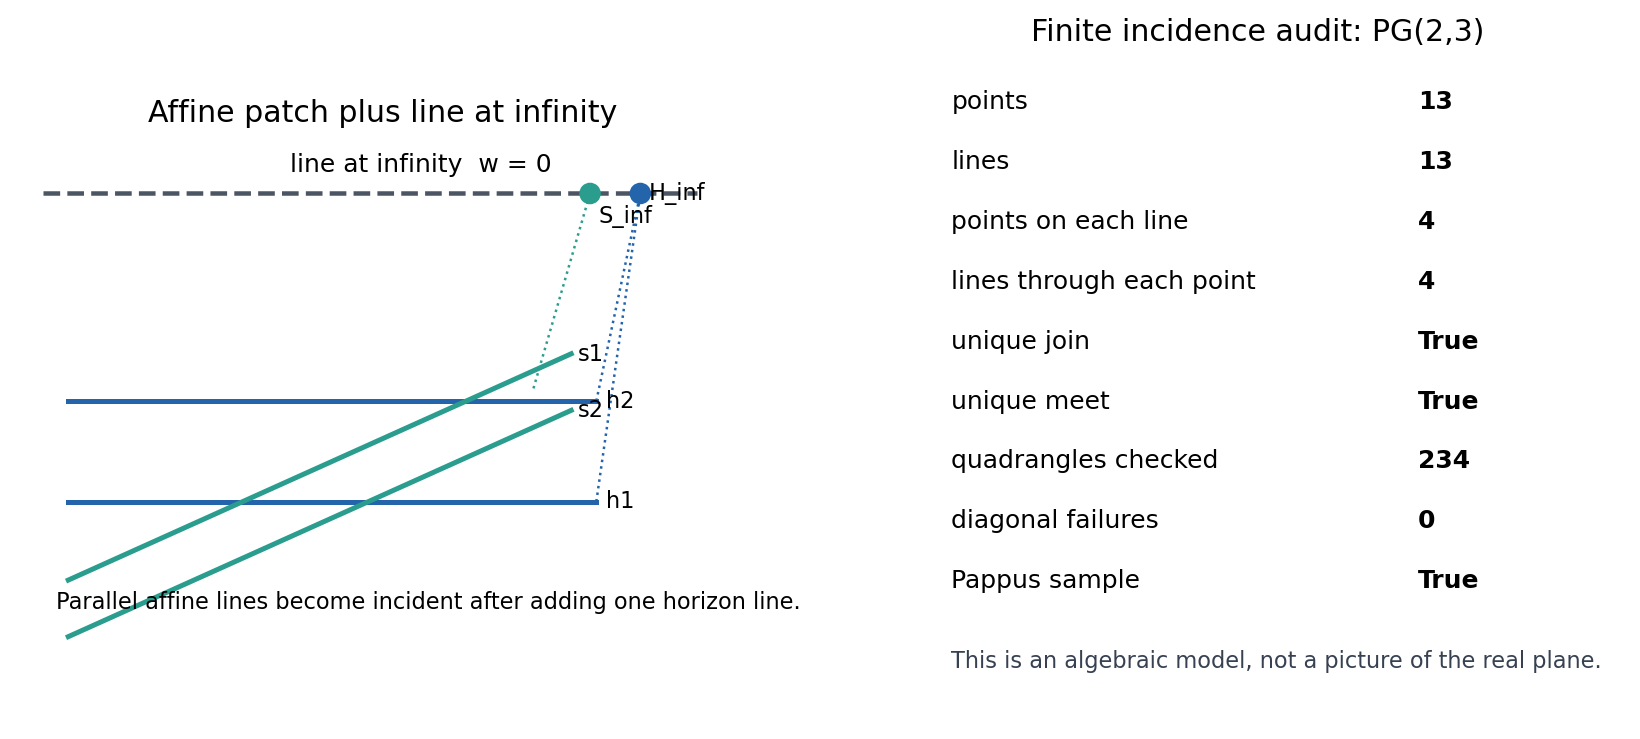

{'field': 'GF(3)',
 'points': 13,
 'lines': 13,
 'points_per_line': [4],
 'lines_through_point': [4],
 'unique_join_ok': True,
 'unique_meet_ok': True,
 'quadrangles_checked': 234,
 'diagonal_collinear_failures': 0,
 'pappus_sample_ok': True}

In [3]:
p = 3
points, lines, inc = finite_projective_plane(p)
line_points = {L: [P for P in points if inc[(P, L)]] for L in lines}
point_lines = {P: [L for L in lines if inc[(P, L)]] for P in points}

unique_join_ok = True
for A, B in combinations(points, 2):
    containing = [L for L in lines if inc[(A, L)] and inc[(B, L)]]
    unique_join_ok &= len(containing) == 1

unique_meet_ok = True
for l, m in combinations(lines, 2):
    common = [P for P in points if inc[(P, l)] and inc[(P, m)]]
    unique_meet_ok &= len(common) == 1

quadrangle_count = 0
diagonal_collinear_failures = 0
for A, B, C, D in combinations(points, 4):
    if any(mod_dot(mod_cross(U, V, p), W, p) == 0 for U, V, W in combinations([A, B, C, D], 3)):
        continue
    quadrangle_count += 1
    d1 = mod_cross(mod_cross(A, B, p), mod_cross(C, D, p), p)
    d2 = mod_cross(mod_cross(A, C, p), mod_cross(B, D, p), p)
    d3 = mod_cross(mod_cross(A, D, p), mod_cross(B, C, p), p)
    if mod_dot(mod_cross(d1, d2, p), d3, p) == 0:
        diagonal_collinear_failures += 1

L1, L2 = lines[0], next(L for L in lines[1:] if L != lines[0])
common = [P for P in points if inc[(P, L1)] and inc[(P, L2)]][0]
row1 = [P for P in line_points[L1] if P != common][:3]
row2 = [P for P in line_points[L2] if P != common][:3]
A1, B1, C1 = row1
A2, B2, C2 = row2
A3 = mod_cross(mod_cross(B1, C2, p), mod_cross(B2, C1, p), p)
B3 = mod_cross(mod_cross(C1, A2, p), mod_cross(C2, A1, p), p)
C3 = mod_cross(mod_cross(A1, B2, p), mod_cross(A2, B1, p), p)
pappus_line = mod_cross(A3, B3, p)
pappus_ok = mod_dot(pappus_line, C3, p) == 0

plane_checks = {
    "field": "GF(3)",
    "points": len(points),
    "lines": len(lines),
    "points_per_line": sorted(set(len(v) for v in line_points.values())),
    "lines_through_point": sorted(set(len(v) for v in point_lines.values())),
    "unique_join_ok": bool(unique_join_ok),
    "unique_meet_ok": bool(unique_meet_ok),
    "quadrangles_checked": quadrangle_count,
    "diagonal_collinear_failures": diagonal_collinear_failures,
    "pappus_sample_ok": bool(pappus_ok),
}
assert plane_checks["points"] == 13 and plane_checks["lines"] == 13
assert plane_checks["points_per_line"] == [4]
assert plane_checks["lines_through_point"] == [4]
assert unique_join_ok and unique_meet_ok and diagonal_collinear_failures == 0 and pappus_ok
chapter_checks["projective_plane_axioms"] = plane_checks

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8))
ax = axes[0]
ax.set_title("Affine patch plus line at infinity")
ax.set_xlim(-2.2, 3.6)
ax.set_ylim(-1.0, 3.0)
ax.set_aspect("equal")
ax.axis("off")
for y, label in [(0.1, "h1"), (0.9, "h2")]:
    ax.plot([-1.8, 2.4], [y, y], color="#2364aa", lw=2)
    ax.text(2.48, y, label, fontsize=9, va="center")
for x0, label in [(-1.3, "s1"), (-0.3, "s2")]:
    xs = np.array([-1.8, 2.2])
    ys = 0.45 * (xs - x0) - 0.3
    ax.plot(xs, ys, color="#2a9d8f", lw=2)
    ax.text(xs[-1] + 0.05, ys[-1], label, fontsize=9, va="center")
ax.plot([-2.0, 3.2], [2.55, 2.55], color="#4b5563", lw=1.8, ls="--")
ax.text(1.0, 2.72, "line at infinity  w = 0", ha="center", fontsize=10)
ax.scatter([2.75, 2.35], [2.55, 2.55], s=58, color=["#2364aa", "#2a9d8f"], zorder=5)
ax.text(2.82, 2.55, "H_inf", fontsize=9, va="center")
ax.text(2.42, 2.37, "S_inf", fontsize=9, va="center")
ax.plot([2.4, 2.75], [0.1, 2.55], color="#2364aa", lw=1, ls=":")
ax.plot([2.4, 2.75], [0.9, 2.55], color="#2364aa", lw=1, ls=":")
ax.plot([1.9, 2.35], [1.0, 2.55], color="#2a9d8f", lw=1, ls=":")
ax.text(-1.9, -0.75, "Parallel affine lines become incident after adding one horizon line.", fontsize=9)

ax = axes[1]
ax.set_title("Finite incidence audit: PG(2,3)")
ax.axis("off")
rows = [
    ("points", plane_checks["points"]),
    ("lines", plane_checks["lines"]),
    ("points on each line", plane_checks["points_per_line"][0]),
    ("lines through each point", plane_checks["lines_through_point"][0]),
    ("unique join", plane_checks["unique_join_ok"]),
    ("unique meet", plane_checks["unique_meet_ok"]),
    ("quadrangles checked", plane_checks["quadrangles_checked"]),
    ("diagonal failures", plane_checks["diagonal_collinear_failures"]),
    ("Pappus sample", plane_checks["pappus_sample_ok"]),
]
y = 0.92
for key, value in rows:
    ax.text(0.08, y, key, fontsize=10, ha="left")
    ax.text(0.72, y, str(value), fontsize=10, ha="left", fontweight="bold")
    y -= 0.09
ax.text(0.08, 0.08, "This is an algebraic model, not a picture of the real plane.", fontsize=9, color="#374151")

path = artifact("figures", "projective_plane_axioms_and_infinity.png", "projective-plane axioms", "affine completion plus finite-model incidence checks", "Matplotlib, finite-field arithmetic")
savefig(path, fig)
display_artifact(path, width=820)
plane_checks


## 2. Projective Coordinates: Join and Meet

Projective coordinates make the primitive incidence relation algebraic. A point is a nonzero vector up to scale. A line is a nonzero covector up to scale. The line through two points is a cross product, and the point where two lines meet is another cross product. This is the computational version of the chapter's notation for joining points and intersecting lines.


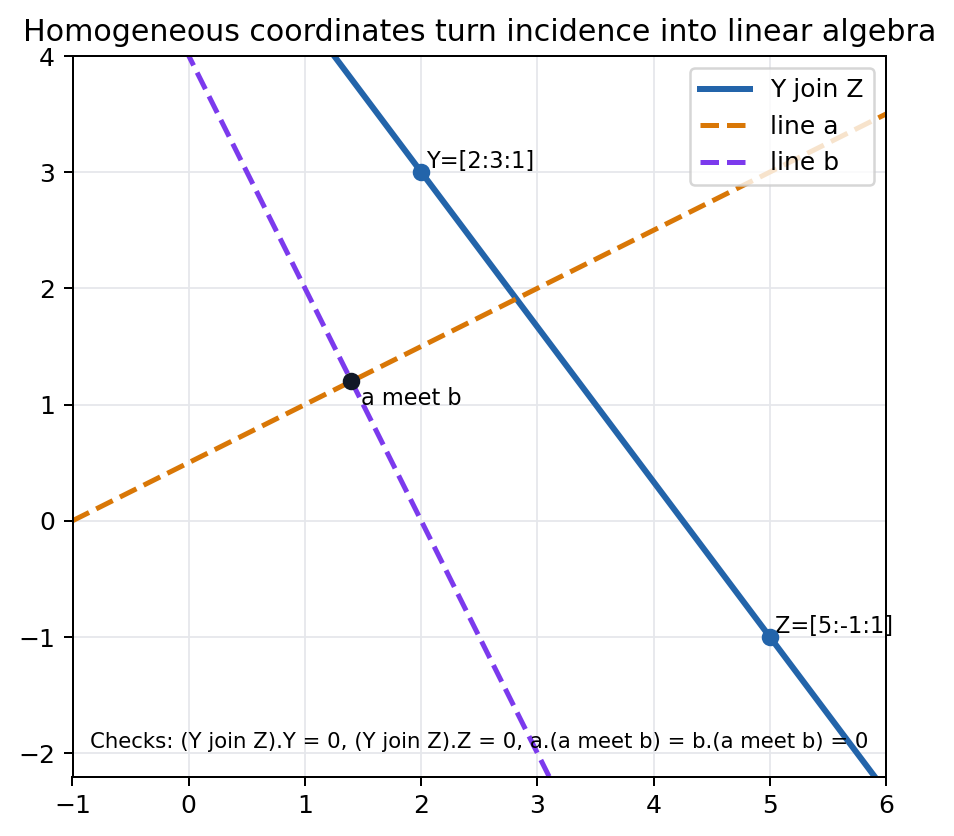

{'join_incidence_Y': 0.0,
 'join_incidence_Z': 0.0,
 'meet_incidence_a': 0.0,
 'meet_incidence_b': 0.0,
 'line_yz': [4.0, 3.0, -17.0],
 'meet_X_normalized': [1.4, 1.2, 1.0]}

In [4]:
Y = np.array([2.0, 3.0, 1.0])
Z = np.array([5.0, -1.0, 1.0])
line_yz = join(Y, Z)
line_a = np.array([1.0, -2.0, 1.0])
line_b = np.array([2.0, 1.0, -4.0])
X = meet(line_a, line_b)
coord_checks = {
    "join_incidence_Y": incidence(line_yz, Y),
    "join_incidence_Z": incidence(line_yz, Z),
    "meet_incidence_a": incidence(line_a, X),
    "meet_incidence_b": incidence(line_b, X),
    "line_yz": [float(v) for v in line_yz],
    "meet_X_normalized": [float(v) for v in normalize_point(X)],
}
assert abs(coord_checks["join_incidence_Y"]) < EPS
assert abs(coord_checks["join_incidence_Z"]) < EPS
assert abs(coord_checks["meet_incidence_a"]) < EPS
assert abs(coord_checks["meet_incidence_b"]) < EPS
chapter_checks["projective_coordinates"] = coord_checks

fig, ax = plt.subplots(figsize=(6.8, 5.2))
ax.set_title("Homogeneous coordinates turn incidence into linear algebra")
ax.set_xlim(-1.0, 6.0)
ax.set_ylim(-2.2, 4.0)
ax.set_aspect("equal")
ax.grid(True, color="#e5e7eb", lw=0.7)
draw_projective_line(ax, line_yz, xlim=(-1, 6), ylim=(-2.2, 4), color="#2364aa", lw=2.4, label="Y join Z")
draw_projective_line(ax, line_a, xlim=(-1, 6), ylim=(-2.2, 4), color="#d97706", lw=2, ls="--", label="line a")
draw_projective_line(ax, line_b, xlim=(-1, 6), ylim=(-2.2, 4), color="#7c3aed", lw=2, ls="--", label="line b")
annotate_point(ax, Y, "Y=[2:3:1]", color="#2364aa")
annotate_point(ax, Z, "Z=[5:-1:1]", color="#2364aa")
annotate_point(ax, X, "a meet b", color="#111827", offset=(0.08, -0.2))
ax.legend(loc="upper right")
ax.text(-0.85, -1.95, "Checks: (Y join Z).Y = 0, (Y join Z).Z = 0, a.(a meet b) = b.(a meet b) = 0", fontsize=8.5)
path = artifact("figures", "projective_coordinates_join_meet.png", "projective coordinates", "join and meet as homogeneous cross products", "Matplotlib, NumPy")
savefig(path, fig)
display_artifact(path, width=680)
coord_checks


## 3. Desargues Theorem: Concurrency Produces an Axis

Desargues theorem is the chapter's first major bridge between a configuration and an invariant. If corresponding vertices of two triangles lie on three concurrent lines, then the three intersections of corresponding sides lie on a single line. The code below builds the configuration from homogeneous coordinates and checks the axis by a determinant.


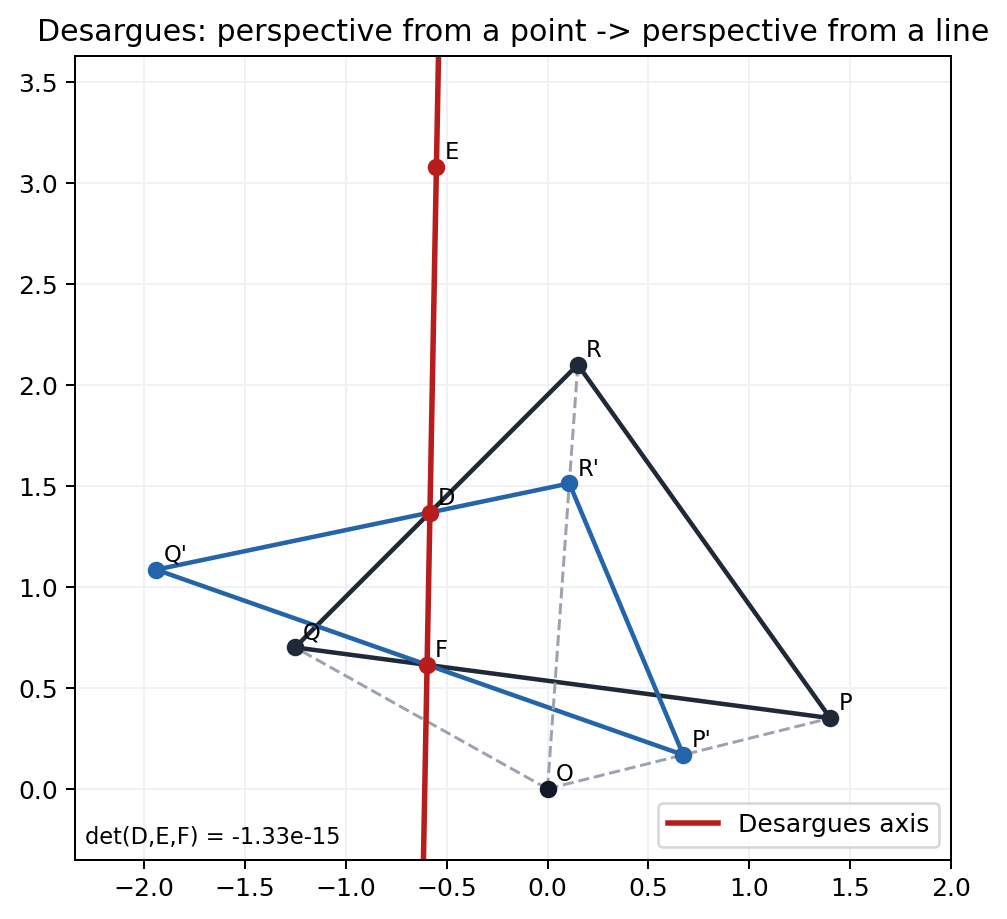

{'center_collinearity_residuals': [0.0, 0.0, 0.0],
 'axis_collinearity_residual': -1.3311071870915515e-15,
 'axis_line': [-2.688375690000001, 0.05032427400000128, -1.6336053934200032]}

In [5]:
O = hp(0.0, 0.0)
P = hp(1.4, 0.35)
Q = hp(-1.25, 0.7)
R = hp(0.15, 2.1)
scales = [0.48, 1.55, 0.72]
P2 = hp(scales[0] * affine(P)[0], scales[0] * affine(P)[1])
Q2 = hp(scales[1] * affine(Q)[0], scales[1] * affine(Q)[1])
R2 = hp(scales[2] * affine(R)[0], scales[2] * affine(R)[1])
D = meet(join(Q, R), join(Q2, R2))
E = meet(join(R, P), join(R2, P2))
F = meet(join(P, Q), join(P2, Q2))
axis = join(D, E)
desargues_residual = collinearity_residual(normalize_point(D), normalize_point(E), normalize_point(F))
center_residuals = [
    collinearity_residual(normalize_point(O), normalize_point(P), normalize_point(P2)),
    collinearity_residual(normalize_point(O), normalize_point(Q), normalize_point(Q2)),
    collinearity_residual(normalize_point(O), normalize_point(R), normalize_point(R2)),
]
assert max(abs(v) for v in center_residuals) < EPS
assert abs(desargues_residual) < 1e-8
chapter_checks["desargues"] = {
    "center_collinearity_residuals": center_residuals,
    "axis_collinearity_residual": desargues_residual,
    "axis_line": [float(v) for v in axis],
}

fig, ax = plt.subplots(figsize=(7.2, 5.8))
ax.set_title("Desargues: perspective from a point -> perspective from a line")
all_pts = np.vstack([affine(x) for x in [O, P, Q, R, P2, Q2, R2, D, E, F]])
ax.set_xlim(all_pts[:,0].min() - 0.4, all_pts[:,0].max() + 0.6)
ax.set_ylim(all_pts[:,1].min() - 0.35, all_pts[:,1].max() + 0.55)
ax.set_aspect("equal")
ax.grid(True, color="#eef2f7")
for U, V in [(P, Q), (Q, R), (R, P)]:
    uv, vv = affine(U), affine(V)
    ax.plot([uv[0], vv[0]], [uv[1], vv[1]], color="#1f2937", lw=1.8)
for U, V in [(P2, Q2), (Q2, R2), (R2, P2)]:
    uv, vv = affine(U), affine(V)
    ax.plot([uv[0], vv[0]], [uv[1], vv[1]], color="#2364aa", lw=1.8)
for U, V in [(O, P), (O, Q), (O, R)]:
    uv, vv = affine(U), affine(V)
    ax.plot([uv[0], vv[0]], [uv[1], vv[1]], color="#9ca3af", lw=1.2, ls="--")
draw_projective_line(ax, axis, xlim=ax.get_xlim(), ylim=ax.get_ylim(), color="#b91c1c", lw=2.2, label="Desargues axis")
for pt, label, color in [(O,"O", "#111827"), (P,"P", "#1f2937"), (Q,"Q", "#1f2937"), (R,"R", "#1f2937"), (P2,"P'", "#2364aa"), (Q2,"Q'", "#2364aa"), (R2,"R'", "#2364aa"), (D,"D", "#b91c1c"), (E,"E", "#b91c1c"), (F,"F", "#b91c1c")]:
    annotate_point(ax, pt, label, color=color)
ax.legend(loc="lower right")
ax.text(ax.get_xlim()[0] + 0.05, ax.get_ylim()[0] + 0.08, f"det(D,E,F) = {desargues_residual:.2e}", fontsize=9)
path = artifact("figures", "desargues_perspective_axis.png", "Desargues theorem", "perspective triangles with checked collinear side-intersections", "Matplotlib, NumPy")
savefig(path, fig)
display_artifact(path, width=740)
chapter_checks["desargues"]


## 4. Quadrangular and Harmonic Sets

A complete quadrangle has four vertices and six sides. When a line cuts opposite side-pairs, the six intersection points have a rigid projective relation. A special case is a harmonic set: two diagonal points of the quadrangle, together with the two intersections on the remaining opposite sides, have cross-ratio `-1`. This is a projective statement, so it survives projectivities even though distances do not.


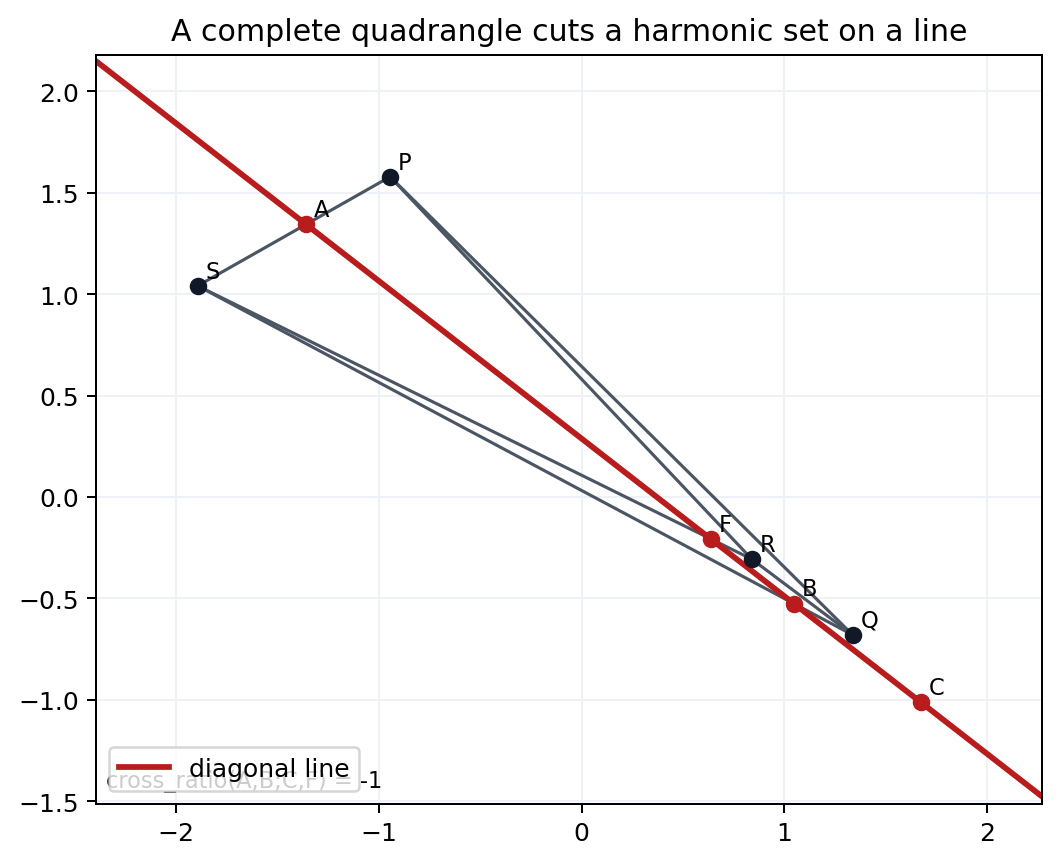

{'line_parameters': {'A': 0.0,
  'B': 1.0,
  'C': 1.2596541224495257,
  'F': 0.8290971412014043},
 'cross_ratio_AB_CF': -0.9999999999999958,
 'cross_ratio_error_from_minus_one': 4.218847493575595e-15}

In [6]:
Pq = hp(-0.944, 1.579)
Qq = hp(1.338, -0.681)
Rq = hp(0.840, -0.307)
Sq = hp(-1.893, 1.041)
A = meet(join(Pq, Sq), join(Qq, Rq))
B = meet(join(Pq, Rq), join(Qq, Sq))
g = join(A, B)
C = meet(g, join(Pq, Qq))
Fh = meet(g, join(Rq, Sq))
tA = point_on_line_parameter(A, B, A)
tB = point_on_line_parameter(A, B, B)
tC = point_on_line_parameter(A, B, C)
tF = point_on_line_parameter(A, B, Fh)
harmonic_cr = cross_ratio(tA, tB, tC, tF)
assert abs(harmonic_cr + 1.0) < 1e-9
chapter_checks["quadrangular_harmonic_set"] = {
    "line_parameters": {"A": tA, "B": tB, "C": tC, "F": tF},
    "cross_ratio_AB_CF": harmonic_cr,
    "cross_ratio_error_from_minus_one": abs(harmonic_cr + 1.0),
}

fig, ax = plt.subplots(figsize=(7.3, 5.4))
ax.set_title("A complete quadrangle cuts a harmonic set on a line")
quad_vertices = [Pq, Qq, Rq, Sq]
all_h = quad_vertices + [A, B, C, Fh]
xy = np.vstack([affine(x) for x in all_h])
ax.set_xlim(xy[:,0].min() - 0.5, xy[:,0].max() + 0.6)
ax.set_ylim(xy[:,1].min() - 0.5, xy[:,1].max() + 0.6)
ax.set_aspect("equal")
ax.grid(True, color="#eef2f7")
for U, V in combinations(quad_vertices, 2):
    uv, vv = affine(U), affine(V)
    ax.plot([uv[0], vv[0]], [uv[1], vv[1]], color="#4b5563", lw=1.25)
draw_projective_line(ax, g, xlim=ax.get_xlim(), ylim=ax.get_ylim(), color="#b91c1c", lw=2.3, label="diagonal line")
for pt, label in [(Pq,"P"), (Qq,"Q"), (Rq,"R"), (Sq,"S")]:
    annotate_point(ax, pt, label, color="#111827")
for pt, label in [(A,"A"), (B,"B"), (C,"C"), (Fh,"F")]:
    annotate_point(ax, pt, label, color="#b91c1c")
ax.legend(loc="lower left")
ax.text(ax.get_xlim()[0] + 0.05, ax.get_ylim()[0] + 0.08, f"cross_ratio(A,B;C,F) = {harmonic_cr:.12g}", fontsize=9)
path = artifact("figures", "quadrangle_harmonic_cross_ratio.png", "quadrangular and harmonic sets", "complete quadrangle section with checked harmonic cross-ratio", "Matplotlib, NumPy")
savefig(path, fig)
display_artifact(path, width=720)
chapter_checks["quadrangular_harmonic_set"]


## 5. Projectivities: Cross-Ratio Survives the Move

A projectivity between ranges can be built from perspectivities, but on a coordinate line it is easiest to see as a fractional linear map. The important invariant is not distance between marks. It is cross-ratio. The symbolic check proves the identity for a general nonsingular fractional linear map, while the interactive artifact shows one concrete range-to-range correspondence.


In [7]:
a, b, c, d, alpha, beta, gamma, delta = sp.symbols("a b c d alpha beta gamma delta")

def cr_sym(A, B, C, D):
    return ((C - A) / (C - B)) / ((D - A) / (D - B))

def mobius(z):
    return (alpha * z + beta) / (gamma * z + delta)

symbolic_identity = sp.factor(cr_sym(mobius(a), mobius(b), mobius(c), mobius(d)) - cr_sym(a, b, c, d))
assert symbolic_identity == 0

params = {"alpha": 2.0, "beta": 1.0, "gamma": 0.35, "delta": 1.2}
def f_num(t):
    return (params["alpha"] * t + params["beta"]) / (params["gamma"] * t + params["delta"])
source_t = np.array([-1.0, 0.25, 1.7, 3.2])
target_t = f_num(source_t)
cr_source = cross_ratio(*source_t)
cr_target = cross_ratio(*target_t)
assert abs(cr_source - cr_target) < 1e-12
projectivity_checks = {
    "symbolic_cross_ratio_identity": str(symbolic_identity),
    "source_parameters": [float(x) for x in source_t],
    "target_parameters": [float(x) for x in target_t],
    "cross_ratio_source": float(cr_source),
    "cross_ratio_target": float(cr_target),
    "cross_ratio_error": float(abs(cr_source - cr_target)),
    "mobius_matrix_determinant": float(params["alpha"] * params["delta"] - params["beta"] * params["gamma"]),
}
chapter_checks["projectivities"] = projectivity_checks

rows = []
for i, (s, t) in enumerate(zip(source_t, target_t), start=1):
    rows.append({"label": f"X{i}", "source_parameter": f"{s:.8g}", "target_parameter": f"{t:.8g}"})
csv_path = artifact("tables", "projectivity_cross_ratio_samples.csv", "projectivities", "sample range correspondence and parameters", "csv")
write_csv(csv_path, rows)

fig = go.Figure()
fig.add_trace(go.Scatter(x=[source_t.min() - 0.5, source_t.max() + 0.5], y=[0, 0], mode="lines", line=dict(color="#1f2937", width=3), name="source range"))
fig.add_trace(go.Scatter(x=[target_t.min() - 0.5, target_t.max() + 0.5], y=[1.4, 1.4], mode="lines", line=dict(color="#2364aa", width=3), name="target range"))
for i, (s, t) in enumerate(zip(source_t, target_t), start=1):
    fig.add_trace(go.Scatter(x=[s, t], y=[0, 1.4], mode="lines+markers+text", text=[f"X{i}", f"X{i}'"], textposition="top center", line=dict(color="#9ca3af", width=1), marker=dict(size=9), showlegend=False))
fig.update_layout(
    title="Projectivity on a range: cross-ratio is unchanged",
    xaxis_title="line coordinate",
    yaxis=dict(visible=False),
    height=430,
    template="plotly_white",
    annotations=[dict(x=float(np.mean(source_t)), y=-0.22, showarrow=False, text=f"CR source = {cr_source:.8g}"), dict(x=float(np.mean(target_t)), y=1.62, showarrow=False, text=f"CR target = {cr_target:.8g}")],
)
html_path = artifact("html", "projectivity_cross_ratio_range.html", "projectivities", "interactive range correspondence preserving cross-ratio", "Plotly, SymPy")
fig.write_html(str(html_path), include_plotlyjs="inline", full_html=True)
display_artifact(html_path, width="100%")
display_artifact(csv_path)
projectivity_checks


{'symbolic_cross_ratio_identity': '0',
 'source_parameters': [-1.0, 0.25, 1.7, 3.2],
 'target_parameters': [-1.1764705882352942,
  1.1650485436893205,
  2.4512534818941507,
  3.1896551724137936],
 'cross_ratio_source': 1.307881773399015,
 'cross_ratio_target': 1.3078817733990147,
 'cross_ratio_error': 2.220446049250313e-16,
 'mobius_matrix_determinant': 2.05}

## 6. Collineations as Homographies

A plane collineation sends points to points and lines to lines. In coordinates it is a nonsingular homogeneous matrix. In computer-vision language the same object appears as a homography. The synthetic grid below is not a borrowed image; it is generated from scratch, warped with OpenCV, and checked by reprojection, line residuals, and cross-ratio.


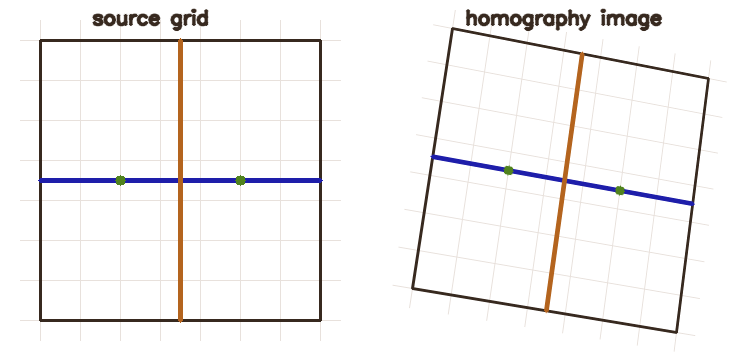

{'matrix': [[0.9465906434701304, -0.14499782949878118, 29.948709386582966],
  [0.18648612548836274, 0.9011086252379202, -15.498180118208833],
  [0.00010101178749123415, -9.600293852472696e-05, 1.0]],
 'determinant': 0.875577478759311,
 'corner_reprojection_max_error': 0.0,
 'row_line_residual': 0.0005247183148610859,
 'cross_ratio_before': 1.2000000000000002,
 'cross_ratio_after': 1.2000000673205515,
 'cross_ratio_error': 6.732055135572068e-08,
 'metric_length_ratio_before': 0.6000000238418579,
 'metric_length_ratio_after': 0.6098071336746216}

In [8]:
size = 360
img = np.full((size, size, 3), 255, np.uint8)
for k in range(40, size, 40):
    color = (220, 225, 232)
    cv2.line(img, (k, 20), (k, size - 20), color, 1)
    cv2.line(img, (20, k), (size - 20, k), color, 1)
cv2.rectangle(img, (40, 40), (320, 320), (31, 41, 55), 2)
cv2.line(img, (40, 180), (320, 180), (170, 30, 30), 3)
cv2.line(img, (180, 40), (180, 320), (30, 100, 180), 3)
cv2.circle(img, (120, 180), 5, (30, 130, 80), -1)
cv2.circle(img, (240, 180), 5, (30, 130, 80), -1)

src = np.float32([[40, 40], [320, 40], [320, 320], [40, 320]])
dst = np.float32([[62, 28], [318, 78], [286, 332], [22, 288]])
H = cv2.getPerspectiveTransform(src, dst)
warped = cv2.warpPerspective(img, H, (size, size), borderValue=(255, 255, 255))
canvas = np.full((size, 2 * size + 30, 3), 255, np.uint8)
canvas[:, :size] = img
canvas[:, size + 30:] = warped
cv2.putText(canvas, "source grid", (92, 24), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (31, 41, 55), 2, cv2.LINE_AA)
cv2.putText(canvas, "homography image", (size + 105, 24), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (31, 41, 55), 2, cv2.LINE_AA)

png_path = artifact("figures", "homography_collineation_grid.png", "collineations", "synthetic grid warped by a projective homography", "OpenCV, NumPy")
cv2.imwrite(str(png_path), canvas)

corners = src.reshape(-1, 1, 2)
reprojected = cv2.perspectiveTransform(corners, H).reshape(-1, 2)
reprojection_error = float(np.max(np.linalg.norm(reprojected - dst, axis=1)))

def transform_points(pts):
    pts = np.asarray(pts, dtype=np.float32).reshape(-1, 1, 2)
    return cv2.perspectiveTransform(pts, H).reshape(-1, 2)

def det_line_residual(pts2):
    h = np.c_[pts2, np.ones(len(pts2))]
    return float(abs(np.linalg.det(h[:3, :])))
row_pts = np.float32([[60, 180], [120, 180], [220, 180], [300, 180]])
row_warp = transform_points(row_pts)
line_residual = det_line_residual(row_warp[:3])
v = row_warp[-1] - row_warp[0]
row_params = [float(np.dot(pt - row_warp[0], v) / np.dot(v, v)) for pt in row_warp]
cr_before = cross_ratio(0.0, (120 - 60) / (300 - 60), (220 - 60) / (300 - 60), 1.0)
cr_after = cross_ratio(*row_params)

metric_before = float(np.linalg.norm(row_pts[1] - row_pts[0]) / np.linalg.norm(row_pts[2] - row_pts[1]))
metric_after = float(np.linalg.norm(row_warp[1] - row_warp[0]) / np.linalg.norm(row_warp[2] - row_warp[1]))
lab_rows = [
    {"quantity": "corner reprojection max error", "before": "0", "after": f"{reprojection_error:.6g}", "interpretation": "homography fits defining correspondences"},
    {"quantity": "row collinearity determinant", "before": "0", "after": f"{line_residual:.6g}", "interpretation": "collineation preserves lines"},
    {"quantity": "cross-ratio on a row", "before": f"{cr_before:.8g}", "after": f"{cr_after:.8g}", "interpretation": "projective measurement survives"},
    {"quantity": "adjacent length ratio", "before": f"{metric_before:.8g}", "after": f"{metric_after:.8g}", "interpretation": "metric measurement generally changes"},
]
lab_path = artifact("tables", "projective_metric_vs_incidence_lab.csv", "applied lab", "metric quantities compared with projective invariants under a homography", "OpenCV, csv")
write_csv(lab_path, lab_rows)

homography_checks = {
    "matrix": [[float(x) for x in row] for row in H],
    "determinant": float(np.linalg.det(H)),
    "corner_reprojection_max_error": reprojection_error,
    "row_line_residual": line_residual,
    "cross_ratio_before": float(cr_before),
    "cross_ratio_after": float(cr_after),
    "cross_ratio_error": float(abs(cr_before - cr_after)),
    "metric_length_ratio_before": metric_before,
    "metric_length_ratio_after": metric_after,
}
assert abs(homography_checks["determinant"]) > EPS
assert reprojection_error < 1e-4
assert line_residual < 1e-2
assert abs(cr_before - cr_after) < 1e-6
chapter_checks["collineation_homography_lab"] = homography_checks

display_artifact(png_path, width=820)
display_artifact(lab_path)
homography_checks


## 7. Correlations, Polarities, and the Conic

A collineation keeps points as points. A correlation swaps the roles of points and lines while preserving incidence in dual form. A polarity is a correlation of period two. With a symmetric nonsingular matrix `Q`, the polar of a point `x` is the line `Qx`, and the self-conjugate points satisfy `x^T Q x = 0`. That quadratic locus is a conic; for a point on the conic, its polar is the tangent.


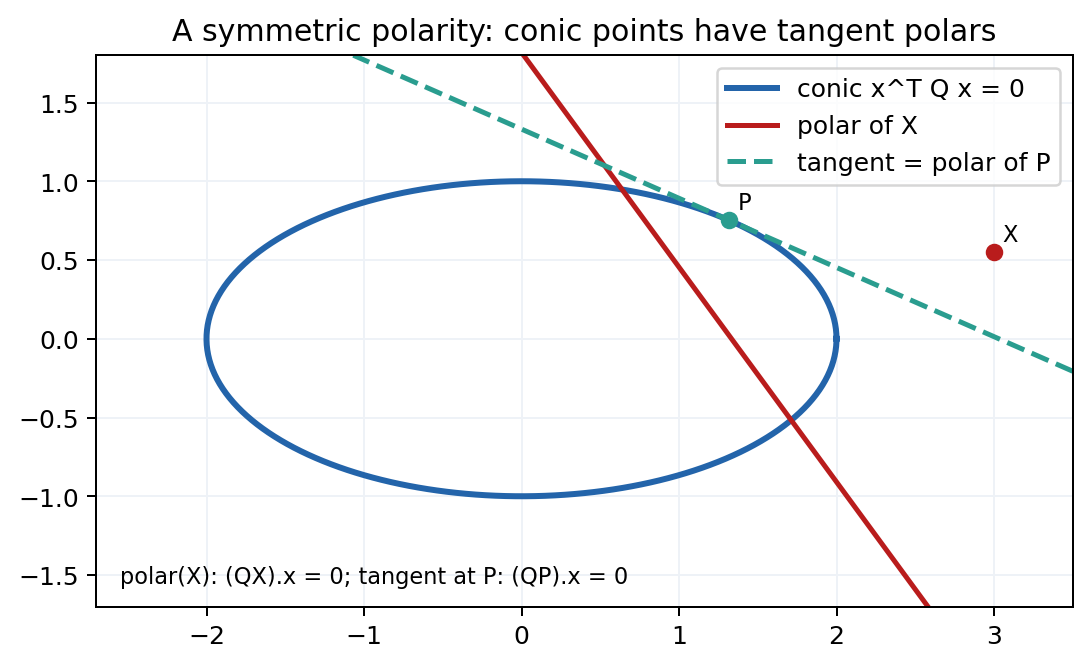

{'Q_symmetric': True,
 'determinant_Q': -0.25,
 'point_on_conic_value': 0.0,
 'tangent_incidence_at_point': 0.0,
 'polar_line_for_external_point': [0.75, 0.55, -1.0]}

In [9]:
Qmat = np.array([[1/4, 0, 0], [0, 1, 0], [0, 0, -1]], dtype=float)
assert np.allclose(Qmat, Qmat.T)
X0 = hp(3.0, 0.55)
polar_X0 = Qmat @ X0
P_on = hp(2 * math.cos(0.85), math.sin(0.85))
tangent_P = Qmat @ P_on
polarity_checks = {
    "Q_symmetric": bool(np.allclose(Qmat, Qmat.T)),
    "determinant_Q": float(np.linalg.det(Qmat)),
    "point_on_conic_value": float(P_on @ Qmat @ P_on),
    "tangent_incidence_at_point": incidence(tangent_P, P_on),
    "polar_line_for_external_point": [float(v) for v in polar_X0],
}
assert polarity_checks["Q_symmetric"]
assert abs(polarity_checks["determinant_Q"]) > EPS
assert abs(polarity_checks["point_on_conic_value"]) < 1e-12
assert abs(polarity_checks["tangent_incidence_at_point"]) < 1e-12
chapter_checks["correlations_polarities"] = polarity_checks

fig, ax = plt.subplots(figsize=(7.0, 5.5))
ax.set_title("A symmetric polarity: conic points have tangent polars")
ax.set_aspect("equal")
ax.set_xlim(-2.7, 3.5)
ax.set_ylim(-1.7, 1.8)
ax.grid(True, color="#eef2f7")
theta = np.linspace(0, 2 * np.pi, 400)
ax.plot(2 * np.cos(theta), np.sin(theta), color="#2364aa", lw=2.4, label="conic x^T Q x = 0")
draw_projective_line(ax, polar_X0, xlim=ax.get_xlim(), ylim=ax.get_ylim(), color="#b91c1c", lw=2, label="polar of X")
draw_projective_line(ax, tangent_P, xlim=ax.get_xlim(), ylim=ax.get_ylim(), color="#2a9d8f", lw=2, ls="--", label="tangent = polar of P")
annotate_point(ax, X0, "X", color="#b91c1c", offset=(0.05, 0.07))
annotate_point(ax, P_on, "P", color="#2a9d8f", offset=(0.05, 0.07))
ax.legend(loc="upper right")
ax.text(-2.55, -1.55, "polar(X): (QX).x = 0; tangent at P: (QP).x = 0", fontsize=9)
path = artifact("figures", "correlation_polarity_conic.png", "correlations and conics", "pole-polar diagram with tangent identity", "Matplotlib, NumPy")
savefig(path, fig)
display_artifact(path, width=700)
polarity_checks


## 8. Pascal on a Conic

The chapter presents conics as projective objects, not as three separate metric curves. Pascal theorem is the decisive incidence test: take six points on a conic, form a hexagon, and the three intersections of opposite sides lie on one line. The diagram is generated from a single conic and checked by one determinant.


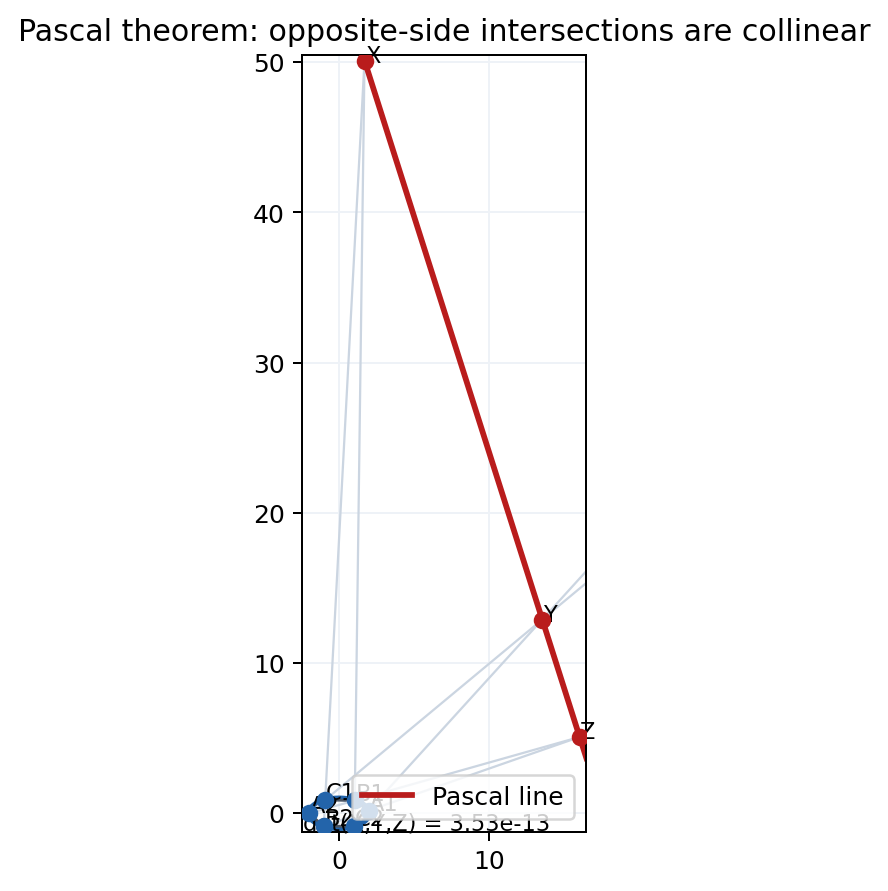

{'pascal_collinearity_residual': 3.525800018245684e-13,
 'pascal_line': [-1.2185829781276762, -0.38759261469629996, 21.48752523583659],
 'six_conic_residuals': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]}

In [10]:
def conic_point(theta_value):
    return hp(2 * math.cos(theta_value), math.sin(theta_value))

angles = [0.18, 1.02, 2.05, 3.15, 4.18, 5.25]
A1, B1, C1, A2, B2, C2 = [conic_point(t) for t in angles]
PX = meet(join(B1, C2), join(B2, C1))
PY = meet(join(C1, A2), join(C2, A1))
PZ = meet(join(A1, B2), join(A2, B1))
pascal_line = join(PX, PY)
pascal_residual = collinearity_residual(normalize_point(PX), normalize_point(PY), normalize_point(PZ))
assert abs(pascal_residual) < 1e-8
pascal_checks = {
    "pascal_collinearity_residual": pascal_residual,
    "pascal_line": [float(v) for v in pascal_line],
    "six_conic_residuals": [float(pt @ Qmat @ pt) for pt in [A1, B1, C1, A2, B2, C2]],
}
assert max(abs(v) for v in pascal_checks["six_conic_residuals"]) < 1e-12
chapter_checks["pascal_conic"] = pascal_checks

fig, ax = plt.subplots(figsize=(8.0, 5.6))
ax.set_title("Pascal theorem: opposite-side intersections are collinear")
all_pascal = [A1, B1, C1, A2, B2, C2, PX, PY, PZ]
xy = np.vstack([affine(x) for x in all_pascal])
ax.set_xlim(xy[:,0].min() - 0.45, xy[:,0].max() + 0.45)
ax.set_ylim(xy[:,1].min() - 0.35, xy[:,1].max() + 0.35)
ax.set_aspect("equal")
ax.grid(True, color="#eef2f7")
theta = np.linspace(0, 2 * np.pi, 400)
ax.plot(2 * np.cos(theta), np.sin(theta), color="#2364aa", lw=2.2)
hex_pts = [A1, B1, C1, A2, B2, C2, A1]
for U, V in zip(hex_pts[:-1], hex_pts[1:]):
    uv, vv = affine(U), affine(V)
    ax.plot([uv[0], vv[0]], [uv[1], vv[1]], color="#4b5563", lw=1.1)
for U, V in [(B1, C2), (B2, C1), (C1, A2), (C2, A1), (A1, B2), (A2, B1)]:
    draw_projective_line(ax, join(U, V), xlim=ax.get_xlim(), ylim=ax.get_ylim(), color="#cbd5e1", lw=0.9)
draw_projective_line(ax, pascal_line, xlim=ax.get_xlim(), ylim=ax.get_ylim(), color="#b91c1c", lw=2.3, label="Pascal line")
for pt, label in [(A1,"A1"), (B1,"B1"), (C1,"C1"), (A2,"A2"), (B2,"B2"), (C2,"C2")]:
    annotate_point(ax, pt, label, color="#2364aa", offset=(0.04, 0.04))
for pt, label in [(PX,"X"), (PY,"Y"), (PZ,"Z")]:
    annotate_point(ax, pt, label, color="#b91c1c", offset=(0.04, -0.12))
ax.legend(loc="lower right")
ax.text(ax.get_xlim()[0] + 0.05, ax.get_ylim()[0] + 0.06, f"det(X,Y,Z) = {pascal_residual:.2e}", fontsize=9)
path = artifact("figures", "pascal_conic_collinearity.png", "conics", "six conic points with checked Pascal line", "Matplotlib, NumPy")
savefig(path, fig)
display_artifact(path, width=780)
pascal_checks


## 9. Projective Space: Skew Lines, Reguli, and Ruled Quadrics

In three-dimensional projective space, lines need not meet. The source uses this to discuss skew lines, transversals, reguli, and ruled quadrics. A one-sheeted hyperboloid is the clean computational model: it is swept out by two line families. Lines in one family are mutually skew in affine space, while every line from one family meets every line from the other family on the quadric.


In [11]:
U = np.linspace(0, 2 * np.pi, 80)
V = np.linspace(-1.25, 1.25, 45)
UU, VV = np.meshgrid(U, V)
Xsurf = np.cosh(VV) * np.cos(UU)
Ysurf = np.cosh(VV) * np.sin(UU)
Zsurf = np.sinh(VV)

def ruling_family(theta_value, sign=1, ts=np.linspace(-1.45, 1.45, 70)):
    if sign == 1:
        x = np.cos(theta_value) - ts * np.sin(theta_value)
        y = np.sin(theta_value) + ts * np.cos(theta_value)
    else:
        x = np.cos(theta_value) + ts * np.sin(theta_value)
        y = np.sin(theta_value) - ts * np.cos(theta_value)
    z = ts
    return x, y, z

fig = go.Figure()
fig.add_trace(go.Surface(x=Xsurf, y=Ysurf, z=Zsurf, opacity=0.32, colorscale="Blues", showscale=False, name="x^2+y^2-z^2=1"))
residuals = []
for theta0 in np.linspace(0, 2 * np.pi, 6, endpoint=False):
    x, y, z = ruling_family(theta0, sign=1)
    residuals.extend((x * x + y * y - z * z - 1).tolist())
    fig.add_trace(go.Scatter3d(x=x, y=y, z=z, mode="lines", line=dict(color="#b91c1c", width=5), name="ruling A", showlegend=False))
for theta0 in np.linspace(np.pi/6, 2 * np.pi + np.pi/6, 6, endpoint=False):
    x, y, z = ruling_family(theta0, sign=-1)
    residuals.extend((x * x + y * y - z * z - 1).tolist())
    fig.add_trace(go.Scatter3d(x=x, y=y, z=z, mode="lines", line=dict(color="#2364aa", width=5), name="ruling B", showlegend=False))
fig.update_layout(
    title="Projective space model: two reguli on a ruled quadric",
    template="plotly_white",
    height=620,
    scene=dict(xaxis_title="x", yaxis_title="y", zaxis_title="z", aspectmode="cube"),
)
regulus_path = artifact("html", "projective_space_regulus_ruled_quadric.html", "projective space", "interactive ruled quadric with two families of generators", "Plotly, NumPy")
fig.write_html(str(regulus_path), include_plotlyjs="inline", full_html=True)
regulus_checks = {
    "quadric_equation": "x^2 + y^2 - z^2 = 1",
    "ruling_sample_count": 12,
    "max_quadric_residual_on_rulings": float(np.max(np.abs(residuals))),
}
assert regulus_checks["max_quadric_residual_on_rulings"] < 1e-12
chapter_checks["projective_space_regulus"] = regulus_checks

display_artifact(regulus_path, width="100%")
regulus_checks


{'quadric_equation': 'x^2 + y^2 - z^2 = 1',
 'ruling_sample_count': 12,
 'max_quadric_residual_on_rulings': 1.1102230246251565e-15}

## 10. Euclidean Space from Projective Space

Projective space becomes affine space when one plane is singled out as the plane at infinity. It becomes Euclidean space when that plane at infinity also carries an absolute polarity. In coordinates with the finite chart `x4 = 1`, directions live on `x4 = 0`; two directions are orthogonal when the absolute polarity pairs them by the dot product `x1 y1 + x2 y2 + x3 y3 = 0`.


In [12]:
phi = np.linspace(0, 2 * np.pi, 70)
psi = np.linspace(0, np.pi, 35)
Phi, Psi = np.meshgrid(phi, psi)
Xs = np.sin(Psi) * np.cos(Phi)
Ys = np.sin(Psi) * np.sin(Phi)
Zs = np.cos(Psi)
polar_phi = np.linspace(0, 2 * np.pi, 160)
polar_x = np.zeros_like(polar_phi)
polar_y = np.cos(polar_phi)
polar_z = np.sin(polar_phi)
v = np.array([1.0, 0.0, 0.0])
w = np.array([0.0, 1.0, 0.0])
u = np.array([1.0, 1.0, 0.0]) / np.sqrt(2)
euclidean_checks = {
    "plane_at_infinity": "x4 = 0",
    "absolute_polarity_condition": "x1*y1 + x2*y2 + x3*y3 = 0",
    "dot_v_w": float(np.dot(v, w)),
    "dot_v_u_nonorthogonal": float(np.dot(v, u)),
}
assert abs(euclidean_checks["dot_v_w"]) < EPS
assert abs(euclidean_checks["dot_v_u_nonorthogonal"]) > 0.1
chapter_checks["euclidean_absolute_polarity"] = euclidean_checks

fig = go.Figure()
fig.add_trace(go.Surface(x=Xs, y=Ys, z=Zs, opacity=0.18, colorscale="Greys", showscale=False, name="directions at infinity"))
fig.add_trace(go.Scatter3d(x=polar_x, y=polar_y, z=polar_z, mode="lines", line=dict(color="#b91c1c", width=6), name="polar great circle of v"))
fig.add_trace(go.Scatter3d(x=[0, v[0]], y=[0, v[1]], z=[0, v[2]], mode="lines+markers+text", text=["", "v"], textposition="top center", line=dict(color="#2364aa", width=7), marker=dict(size=4), name="direction v"))
fig.add_trace(go.Scatter3d(x=[0, w[0]], y=[0, w[1]], z=[0, w[2]], mode="lines+markers+text", text=["", "w"], textposition="top center", line=dict(color="#2a9d8f", width=7), marker=dict(size=4), name="orthogonal direction w"))
fig.add_trace(go.Scatter3d(x=[0, u[0]], y=[0, u[1]], z=[0, u[2]], mode="lines+markers+text", text=["", "u"], textposition="top center", line=dict(color="#d97706", width=5, dash="dash"), marker=dict(size=4), name="nonorthogonal direction u"))
fig.update_layout(
    title="Euclidean structure as an absolute polarity on the plane at infinity",
    template="plotly_white",
    height=620,
    scene=dict(xaxis_title="x1", yaxis_title="x2", zaxis_title="x3", aspectmode="cube"),
)
abs_path = artifact("html", "euclidean_space_absolute_polarity.html", "Euclidean space", "interactive direction sphere showing absolute polarity and orthogonality", "Plotly, NumPy")
fig.write_html(str(abs_path), include_plotlyjs="inline", full_html=True)
display_artifact(abs_path, width="100%")
euclidean_checks


{'plane_at_infinity': 'x4 = 0',
 'absolute_polarity_condition': 'x1*y1 + x2*y2 + x3*y3 = 0',
 'dot_v_w': 0.0,
 'dot_v_u_nonorthogonal': 0.7071067811865475}

## Applied Lab: What Changes Under a Projective Move?

Use the homography table above as a diagnostic lab. The row collinearity determinant and cross-ratio stay small because they are projective invariants. The length ratio changes because it depends on the Euclidean chart and metric. This is the habit to build for the chapter: ask whether a statement is incidence/projective, affine, or metric before expecting it to survive a transformation.


In [13]:
with (ART["tables"] / "projective_metric_vs_incidence_lab.csv").open(newline="", encoding="utf-8") as handle:
    lab_table = list(csv.DictReader(handle))
lines_md = ["| quantity | before | after | interpretation |", "| --- | ---: | ---: | --- |"]
for row in lab_table:
    lines_md.append(f"| {row['quantity']} | {row['before']} | {row['after']} | {row['interpretation']} |")
display(Markdown("\n".join(lines_md)))
lab_table


| quantity | before | after | interpretation |
| --- | ---: | ---: | --- |
| corner reprojection max error | 0 | 0 | homography fits defining correspondences |
| row collinearity determinant | 0 | 0.000524718 | collineation preserves lines |
| cross-ratio on a row | 1.2 | 1.2000001 | projective measurement survives |
| adjacent length ratio | 0.60000002 | 0.60980713 | metric measurement generally changes |

[{'quantity': 'corner reprojection max error',
  'before': '0',
  'after': '0',
  'interpretation': 'homography fits defining correspondences'},
 {'quantity': 'row collinearity determinant',
  'before': '0',
  'after': '0.000524718',
  'interpretation': 'collineation preserves lines'},
 {'quantity': 'cross-ratio on a row',
  'before': '1.2',
  'after': '1.2000001',
  'interpretation': 'projective measurement survives'},
 {'quantity': 'adjacent length ratio',
  'before': '0.60000002',
  'after': '0.60980713',
  'interpretation': 'metric measurement generally changes'}]

## How To Use The Projective Checks

The projective artifacts should be read as a ladder of invariants. First, incidence checks decide whether a point lies on a line, whether two lines meet in the expected point, and whether three constructed points are collinear. Second, coordinate checks show that changing a homogeneous representative does not change the geometric object. Third, cross-ratio and harmonic checks identify the quantities that survive every projectivity on a line. Finally, the conic and polarity checks show how a metric-looking statement can be encoded projectively before Euclidean distance is reintroduced.

That order matters. If a visual looks persuasive but fails a determinant or incidence residual, the problem is projective, not cosmetic. If incidence and cross-ratio survive while a length ratio changes, the visual is doing exactly what projective geometry promises: preserving relation and forgetting measurement until an affine chart or absolute polarity is chosen.

## Takeaways

- Projective geometry keeps incidence and cross-ratio while deliberately forgetting distance, angle, order, and ordinary parallelism.
- Homogeneous coordinates make joins, meets, collineations, correlations, and conics auditable with dot products, cross products, determinants, and symmetric bilinear forms.
- Desargues and Pascal are not decorative configurations: each gives a specific collinearity invariant that can be tested numerically.
- Harmonic sets are the projective replacement for a metric midpoint-style relation; the stable quantity is cross-ratio `-1`.
- Projective space adds skew lines, reguli, and quadrics; Euclidean space returns only after choosing a plane at infinity and an absolute polarity on it.


In [14]:
checks_path = ART["checks"] / "chapter_14_invariant_checks.json"
write_json(checks_path, chapter_checks)
artifact_records.append({
    "concept": "chapter invariant checks",
    "kind": "checks",
    "path": book_relative(checks_path, BOOK_ROOT),
    "role": "numeric and symbolic validation payload for all projective artifacts",
    "library": "json",
})
manifest_path = ART["tables"] / "artifact_manifest.csv"
write_csv(manifest_path, artifact_records)

visual_summary = {
    "chapter": CHAPTER_NO,
    "title": chapter["title"],
    "source_span": chapter_checks["source_span"],
    "figures": [record["path"] for record in artifact_records if record["kind"] == "figures"],
    "html": [record["path"] for record in artifact_records if record["kind"] == "html"],
    "tables": [record["path"] for record in artifact_records if record["kind"] == "tables"],
    "checks": [book_relative(checks_path, BOOK_ROOT)],
}
visual_summary_path = ART["checks"] / "visual_summary.json"
write_json(visual_summary_path, visual_summary)

all_artifacts = []
for record in artifact_records:
    all_artifacts.append(BOOK_ROOT / record["path"])
all_artifacts.extend([checks_path, manifest_path, visual_summary_path])
seen = set()
all_artifacts = [p for p in all_artifacts if not (str(p) in seen or seen.add(str(p)))]
assert_artifacts(all_artifacts, min_bytes=100)

assert chapter_checks["projective_plane_axioms"]["unique_join_ok"]
assert chapter_checks["projective_plane_axioms"]["diagonal_collinear_failures"] == 0
assert abs(chapter_checks["desargues"]["axis_collinearity_residual"]) < 1e-8
assert chapter_checks["quadrangular_harmonic_set"]["cross_ratio_error_from_minus_one"] < 1e-9
assert chapter_checks["projectivities"]["symbolic_cross_ratio_identity"] == "0"
assert chapter_checks["collineation_homography_lab"]["cross_ratio_error"] < 1e-6
assert chapter_checks["correlations_polarities"]["Q_symmetric"]
assert abs(chapter_checks["pascal_conic"]["pascal_collinearity_residual"]) < 1e-8
assert chapter_checks["projective_space_regulus"]["max_quadric_residual_on_rulings"] < 1e-12
assert abs(chapter_checks["euclidean_absolute_polarity"]["dot_v_w"]) < EPS

final_sanity = {
    "artifact_count": len(all_artifacts),
    "artifacts": {book_relative(path, BOOK_ROOT): path.stat().st_size for path in all_artifacts},
    "core_checks": {
        "pg23_incidence": True,
        "desargues_axis": chapter_checks["desargues"]["axis_collinearity_residual"],
        "harmonic_cross_ratio_error": chapter_checks["quadrangular_harmonic_set"]["cross_ratio_error_from_minus_one"],
        "projectivity_cross_ratio_error": chapter_checks["projectivities"]["cross_ratio_error"],
        "homography_cross_ratio_error": chapter_checks["collineation_homography_lab"]["cross_ratio_error"],
        "pascal_residual": chapter_checks["pascal_conic"]["pascal_collinearity_residual"],
        "regulus_residual": chapter_checks["projective_space_regulus"]["max_quadric_residual_on_rulings"],
        "absolute_polarity_dot": chapter_checks["euclidean_absolute_polarity"]["dot_v_w"],
    },
}
final_path = ART["checks"] / "final_sanity.json"
write_json(final_path, final_sanity)
assert_artifacts([final_path], min_bytes=100)
display_artifact(manifest_path)
display_artifact(checks_path)
display_artifact(final_path)
display_artifact(visual_summary_path)
final_sanity


{'artifact_count': 15,
 'artifacts': {'artifacts/chapter-14/checks/storyboard.json': 1222,
  'artifacts/chapter-14/figures/projective_plane_axioms_and_infinity.png': 95392,
  'artifacts/chapter-14/figures/projective_coordinates_join_meet.png': 55554,
  'artifacts/chapter-14/figures/desargues_perspective_axis.png': 78928,
  'artifacts/chapter-14/figures/quadrangle_harmonic_cross_ratio.png': 93696,
  'artifacts/chapter-14/tables/projectivity_cross_ratio_samples.csv': 114,
  'artifacts/chapter-14/html/projectivity_cross_ratio_range.html': 4855329,
  'artifacts/chapter-14/figures/homography_collineation_grid.png': 74293,
  'artifacts/chapter-14/tables/projective_metric_vs_incidence_lab.csv': 337,
  'artifacts/chapter-14/figures/correlation_polarity_conic.png': 83875,
  'artifacts/chapter-14/figures/pascal_conic_collinearity.png': 60221,
  'artifacts/chapter-14/html/projective_space_regulus_ruled_quadric.html': 5038944,
  'artifacts/chapter-14/html/euclidean_space_absolute_polarity.html': 4